# ASNR Graph Classification
Classifying animal social networks by interaction type and biological class using GNNs.


## Data Loading

In [1]:
from pathlib import Path
import networkx as nx
import pandas as pd

folder_path = Path('./asnr datasets')
assert folder_path.exists() #if crashing here, fix your filepath / working directory

asnr_graphs = {}
for file_path in folder_path.glob('*.graphml'):
    graph = nx.read_graphml(file_path)
    asnr_graphs[file_path.stem + '.graphml'] = graph

info_frame = pd.read_csv(folder_path / 'Network_summary_masterfile.csv')


In [3]:
print(f'Loaded {len(asnr_graphs)} graphs')
print("Column Names:")
print(info_frame.columns.tolist())

Loaded 1197 graphs
Column Names:
['Network_ID', 'Network_Identifiers', 'class', 'genus', 'species', 'interaction_type', 'definition_of_interaction', 'edge_wt_type', 'geographical_location', 'population_type', 'data_record_technique', 'time_span', 'resolution', 'time_span_per_day', 'attributes_available', 'is_connected', 'num_components', 'nodes', 'edges', 'network.density', 'highest.degree', 'avg.degree', 'std.degree.node', 'CV.degree', 'skewness', 'avg.node.strength', 'std.node.strength', 'CV.node.strength', 'avg.edge.strength', 'std.edge.strength', 'CV.edge.strength', 'highest.node.strength', 'deg.assort', 'avg.betw.centrality', 'std.betw.centrality', 'highest.betw', 'avg.betw.centrality.weighted', 'std.betw.centrality.weighted', 'highest.betw.weighted', 'clustering', 'clustering.weighted', 'transitivity', 'Q', 'Qmax', 'Qrel', 'cohesion', 'num.modules', 'avg.modsize', 'diameter', 'Citation']


## Exploratory Data Analysis

In [4]:
print('Biological class counts:')
print(info_frame['class'].value_counts())
print("\n")
print('Interaction type counts:')
print(info_frame['interaction_type'].value_counts())

Biological class counts:
class
Mammalia          560
Insecta           287
Aves              185
Actinopterygii    101
Reptilia           59
Arachnida           2
Amphibia            2
Cephalapoda         1
Name: count, dtype: int64


Interaction type counts:
interaction_type
social_projection_bipartite        343
physical_contact                   271
spatial_proximity                  200
grooming                           136
dominance                          107
FE_mating                           58
non_physical_social_interaction     21
food_sharing                        19
trophallaxis                        16
group_membership                    16
overall_mix                          3
NFE_mating                           3
foraging                             2
Avoidance                            2
Name: count, dtype: int64


In [5]:
# Cross Tabulation
crosstab = pd.crosstab(info_frame['class'], info_frame['interaction_type'])
#print('Graphs per (class, interaction_type):')
#print(crosstab)

crosstab_table = (
    crosstab.style
    .background_gradient(cmap='viridis')
    .set_caption('Graphs per (class, interaction_type)')
)

# If using Jupyter Notebook:
display(crosstab_table)

interaction_type,Avoidance,FE_mating,NFE_mating,dominance,food_sharing,foraging,grooming,group_membership,non_physical_social_interaction,overall_mix,physical_contact,social_projection_bipartite,spatial_proximity,trophallaxis
class,,,,,,,,,,,,,,
Actinopterygii,0,0,0,56,0,0,0,7,0,0,0,0,38,0
Amphibia,0,0,2,0,0,0,0,0,0,0,0,0,0,0
Arachnida,0,1,0,0,0,0,0,0,0,0,1,0,0,0
Aves,0,25,0,28,18,2,19,5,19,0,19,30,20,0
Cephalapoda,0,0,1,0,0,0,0,0,0,0,0,0,0,0
Insecta,0,15,0,0,0,0,0,0,0,0,244,0,12,16
Mammalia,2,16,0,23,1,0,117,4,2,3,7,260,125,0
Reptilia,0,1,0,0,0,0,0,0,0,0,0,53,5,0


#### Also show in matplotlib

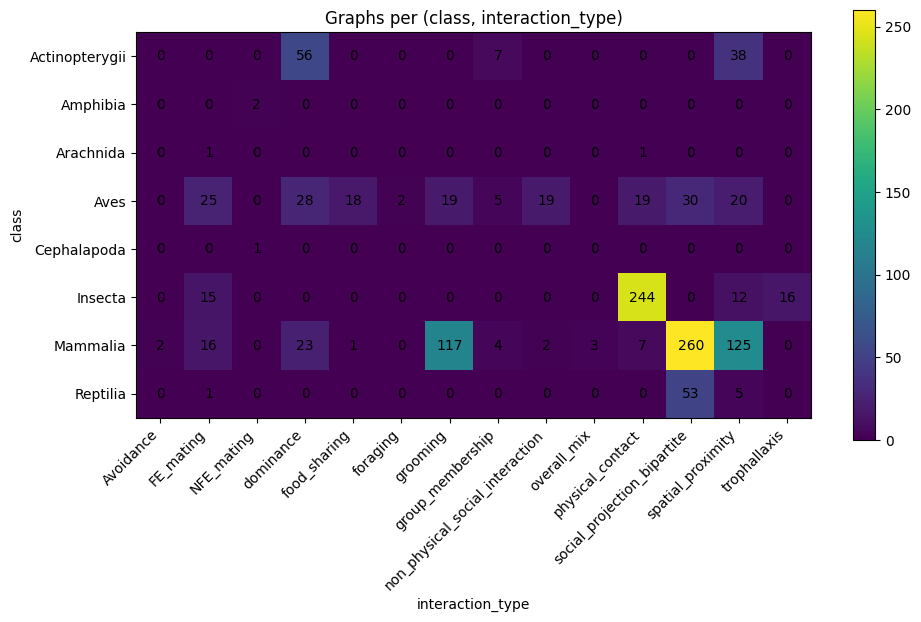

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(crosstab.values)

# Axis labels
ax.set_xticks(range(len(crosstab.columns)))
ax.set_xticklabels(crosstab.columns, rotation=45, ha='right')

ax.set_yticks(range(len(crosstab.index)))
ax.set_yticklabels(crosstab.index)

# Add cell values
for i in range(len(crosstab.index)):
    for j in range(len(crosstab.columns)):
        ax.text(
            j, i,
            crosstab.iloc[i, j],
            ha='center',
            va='center'
        )

# Titles
ax.set_title('Graphs per (class, interaction_type)')
ax.set_xlabel('interaction_type')
ax.set_ylabel('class')

# Color bar
fig.colorbar(im)

plt.tight_layout()
plt.show()

## Feature Distribution by Biological Class / Interaction Type

In [7]:
# Structural feature distributions per biological class 
import numpy as np
import matplotlib.pyplot as plt

def compute_graph_features(graph):
    """Compute a dict of structural graph features using NetworkX."""
    n = graph.number_of_nodes()
    m = graph.number_of_edges()
    degrees = [d for _, d in graph.degree()]

    # Use undirected version for clustering / path length
    G_und = graph.to_undirected() if graph.is_directed() else graph

    #NOTE: Have to use try / except here, since some of the data is messy, not numbers or empty graphs
    try:
        avg_clustering = nx.average_clustering(G_und)
    except Exception:
        avg_clustering = float('nan')

    try:
        # Only for connected graphs; use largest component otherwise
        if nx.is_connected(G_und):
            avg_path = nx.average_shortest_path_length(G_und)
        else:
            largest_cc = G_und.subgraph(max(nx.connected_components(G_und), key=len))
            avg_path = nx.average_shortest_path_length(largest_cc)
    except Exception:
        avg_path = float('nan')

    density = nx.density(G_und)

    return {
        'n_nodes': n,
        'n_edges': m,
        'mean_degree': np.mean(degrees),
        'std_degree': np.std(degrees),
        'density': density,
        'avg_clustering': avg_clustering,
        'avg_path_length': avg_path,
    }

# Compute features for every graph in the metadata
feature_rows = []
for _, row in info_frame.iterrows():
    nid = row['Network_ID']
    if nid not in asnr_graphs:
        continue
    feats = compute_graph_features(asnr_graphs[nid])
    feats['Network_ID'] = nid
    feats['class'] = row['class']
    feats['interaction_type'] = row['interaction_type']
    feature_rows.append(feats)

feat_df = pd.DataFrame(feature_rows)
print(feat_df.groupby('class')[['mean_degree', 'density', 'avg_clustering', 'avg_path_length']].median())

C:\Users\BetterOffBread\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\BetterOffBread\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\BetterOffBread\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\BetterOffBread\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\_methods.py

                mean_degree   density  avg_clustering  avg_path_length
class                                                                 
Actinopterygii     6.000000  0.777778        0.861376         1.194444
Amphibia           1.295455  0.065448        0.000000         1.633333
Arachnida          7.153602  0.420757        0.445040         1.998611
Aves               5.531250  0.533333        0.708251         1.400000
Cephalapoda        1.433962  0.027576        0.000000         1.750000
Insecta           64.292135  0.685057        0.786657         1.314943
Mammalia           3.728814  0.250000        0.533766         1.979167
Reptilia           0.875000  0.016129        0.136364         1.722222


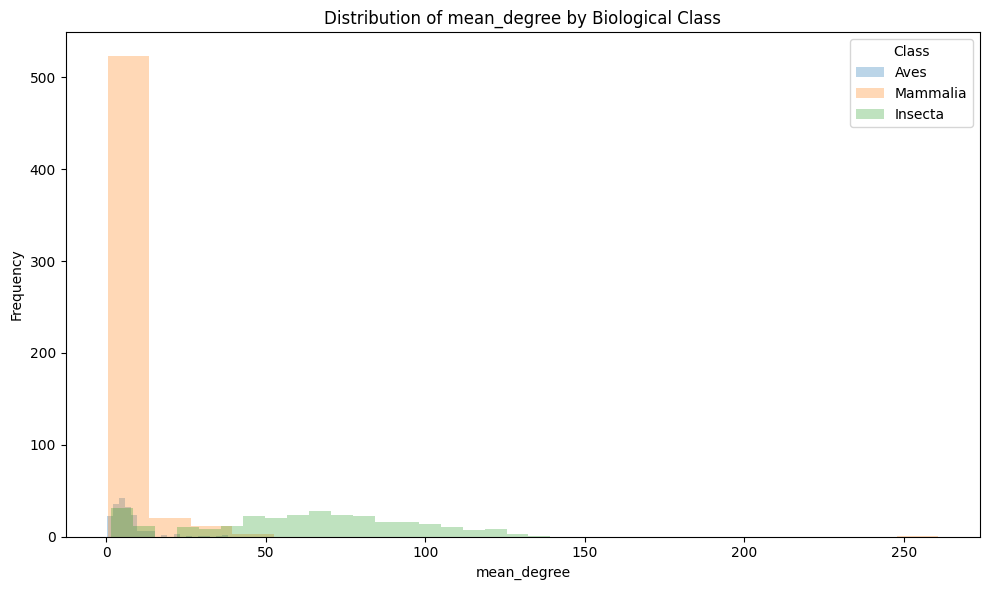

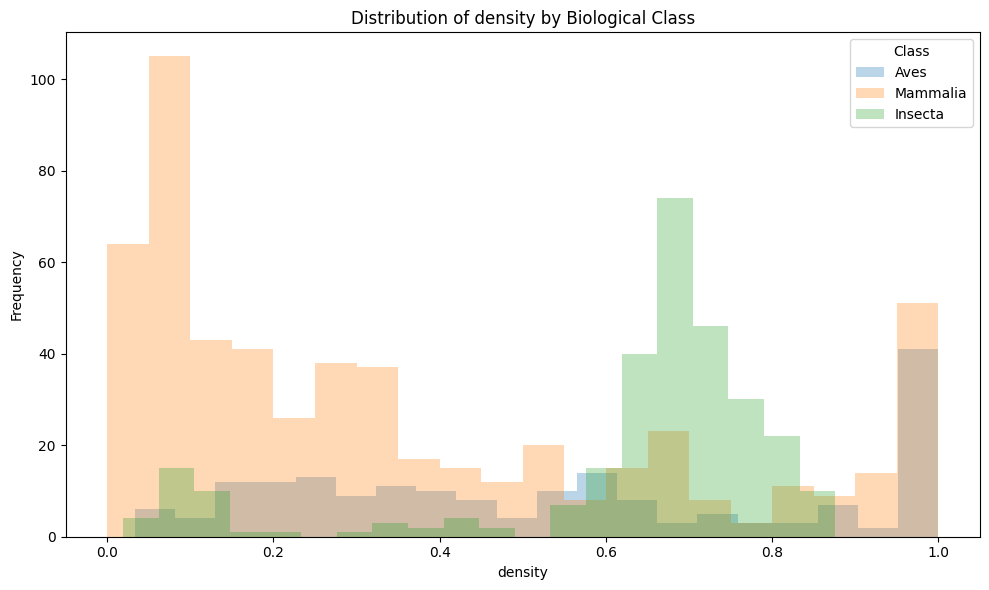

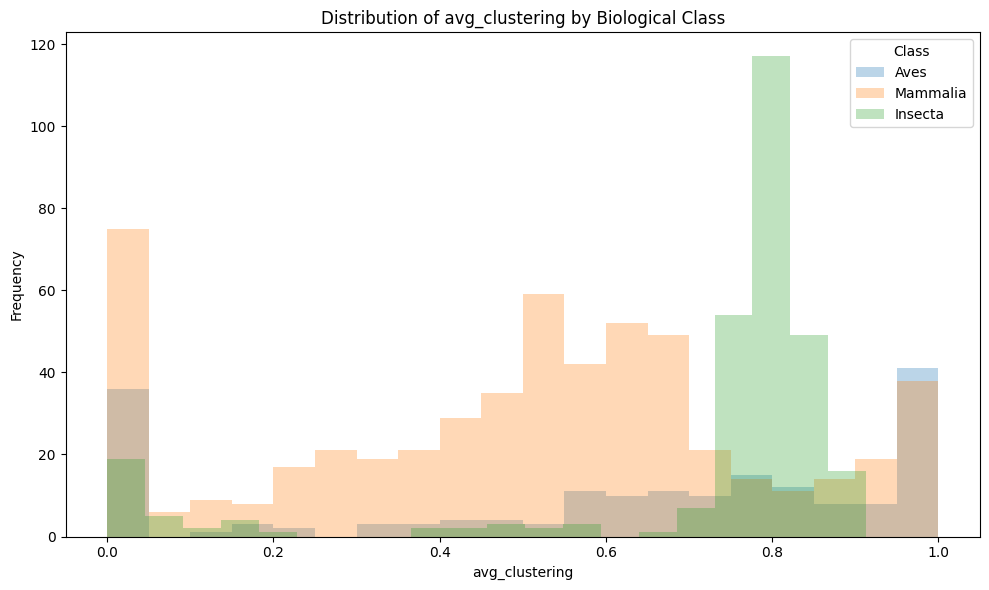

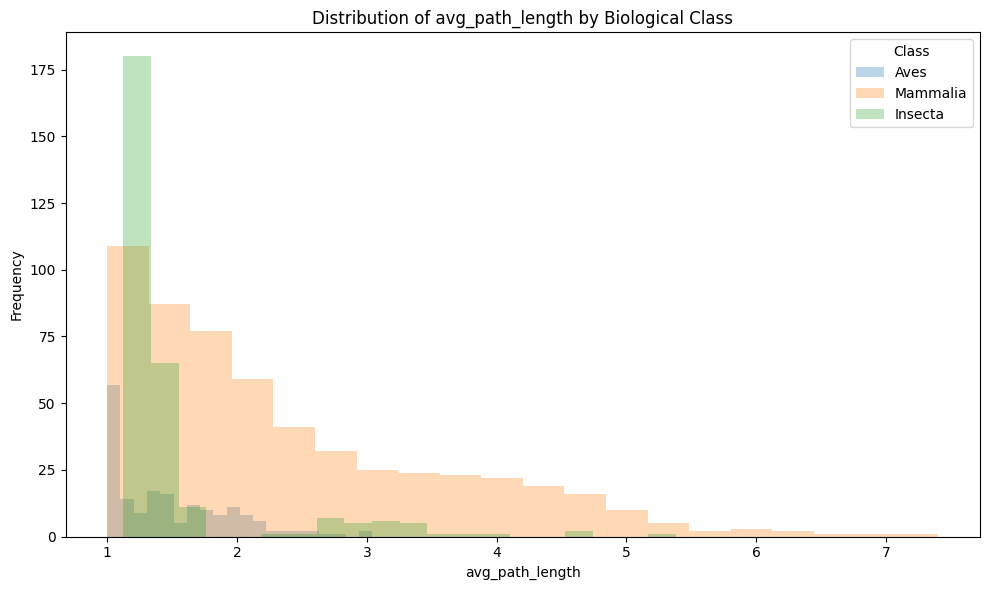

In [8]:
# Histograms of Features by class
features_to_plot = [
    'mean_degree',
    'density',
    'avg_clustering',
    'avg_path_length'
]

classes = feat_df['class'].unique()

classes = ['Aves', 'Mammalia', 'Insecta']

for feature in features_to_plot:

    plt.figure(figsize=(10, 6))

    for cls in classes:

        subset = feat_df[feat_df['class'] == cls]

        plt.hist(
            subset[feature].dropna(),
            bins=20,
            alpha=0.3,
            label=cls
        )

    plt.title(f'Distribution of {feature} by Biological Class')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.legend(title='Class')

    plt.tight_layout()
    plt.show()

C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_57492\3278248475.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_class, labels=bio_classes)
C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_57492\3278248475.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_class, labels=bio_classes)
C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_57492\3278248475.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_class, labels=bio_classes)
C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_57492\3278248475.py:10: MatplotlibDeprecationWarning: The 'lab

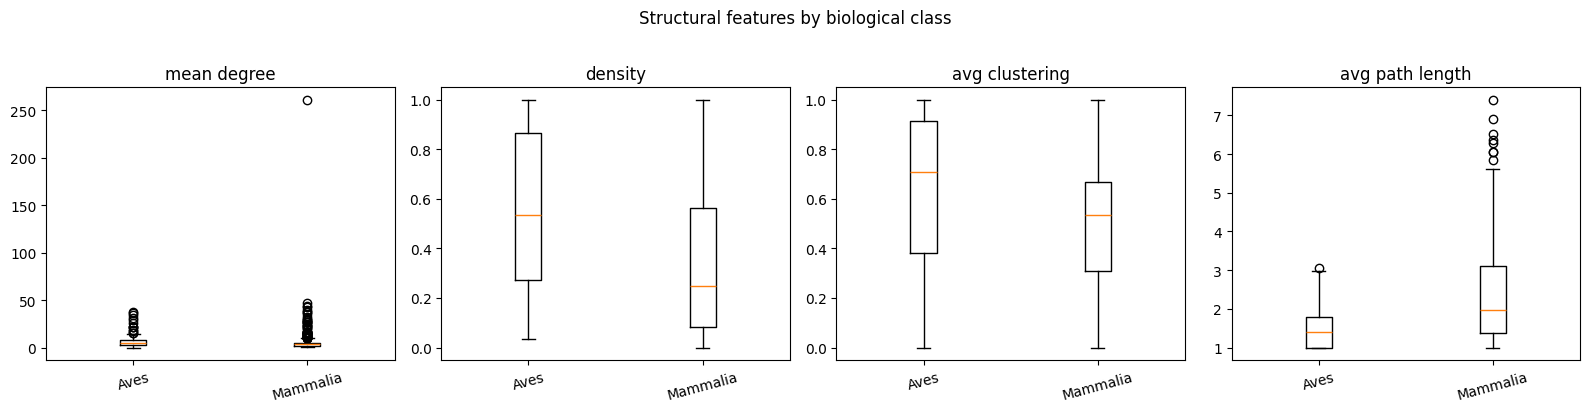

In [9]:
#Box plots of structural features per biological class
features_to_plot = ['mean_degree', 'density', 'avg_clustering', 'avg_path_length']
bio_classes = feat_df['class'].dropna().unique()
#bio_classes = ['Aves', 'Mammalia', 'Insecta']
bio_classes = ['Aves', 'Mammalia']

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(16, 4))
for ax, feat in zip(axes, features_to_plot):
    data_per_class = [feat_df[feat_df['class'] == c][feat].dropna().values for c in bio_classes]
    ax.boxplot(data_per_class, labels=bio_classes)
    ax.set_title(feat.replace('_', ' '))
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Structural features by biological class', y=1.02)
plt.tight_layout()
plt.savefig('eda_structural_features.pdf', bbox_inches='tight')
plt.show()

### Features by Interaction Type

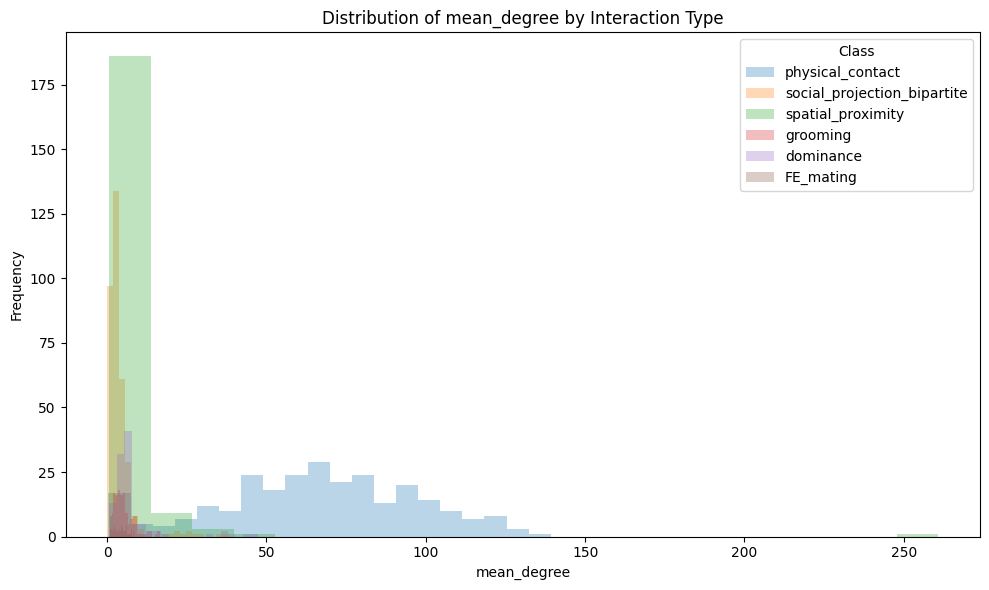

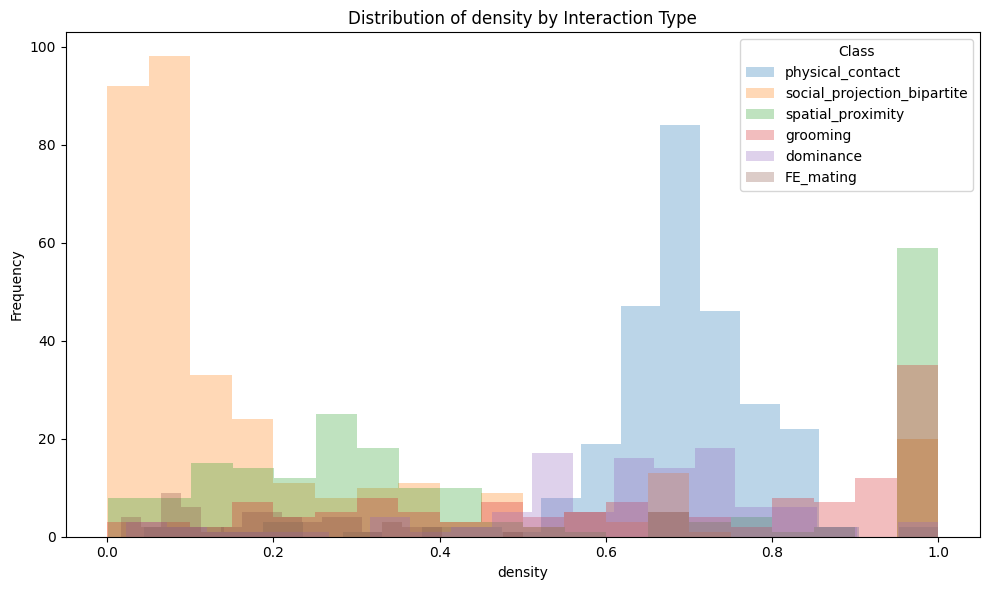

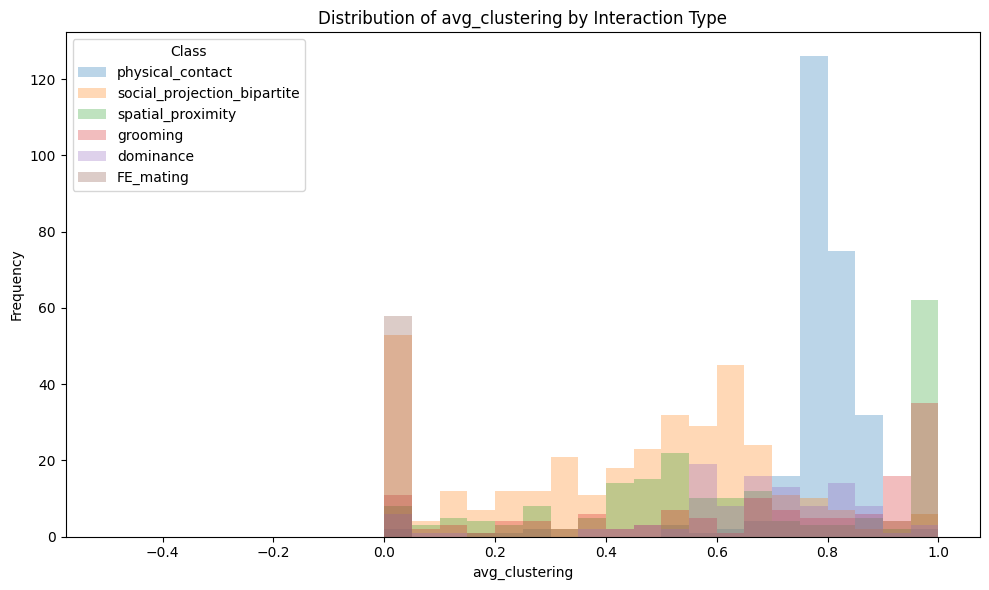

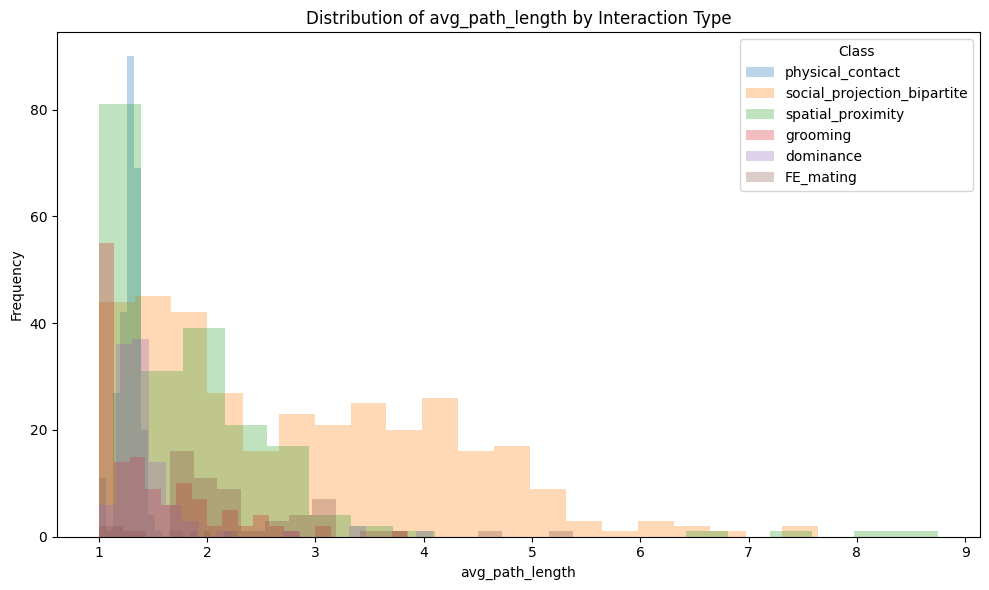

In [10]:
# Histograms of Features by class
features_to_plot = [
    'mean_degree',
    'density',
    'avg_clustering',
    'avg_path_length'
]

interactions = feat_df['interaction_type'].unique()

interactions = ['physical_contact', 'social_projection_bipartite', 'spatial_proximity', 'grooming','dominance','FE_mating']

for feature in features_to_plot:

    plt.figure(figsize=(10, 6))

    for tp in interactions:

        subset = feat_df[feat_df['interaction_type'] == tp]

        plt.hist(
            subset[feature].dropna(),
            bins=20,
            alpha=0.3,
            label=tp
        )

    plt.title(f'Distribution of {feature} by Interaction Type')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.legend(title='Class')

    plt.tight_layout()
    plt.show()

C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_57492\3443119044.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_class, labels=inter_classes)
C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_57492\3443119044.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_class, labels=inter_classes)
C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_57492\3443119044.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_class, labels=inter_classes)
C:\Users\BetterOffBread\AppData\Local\Temp\ipykernel_57492\3443119044.py:9: MatplotlibDeprecationWarning: The 'l

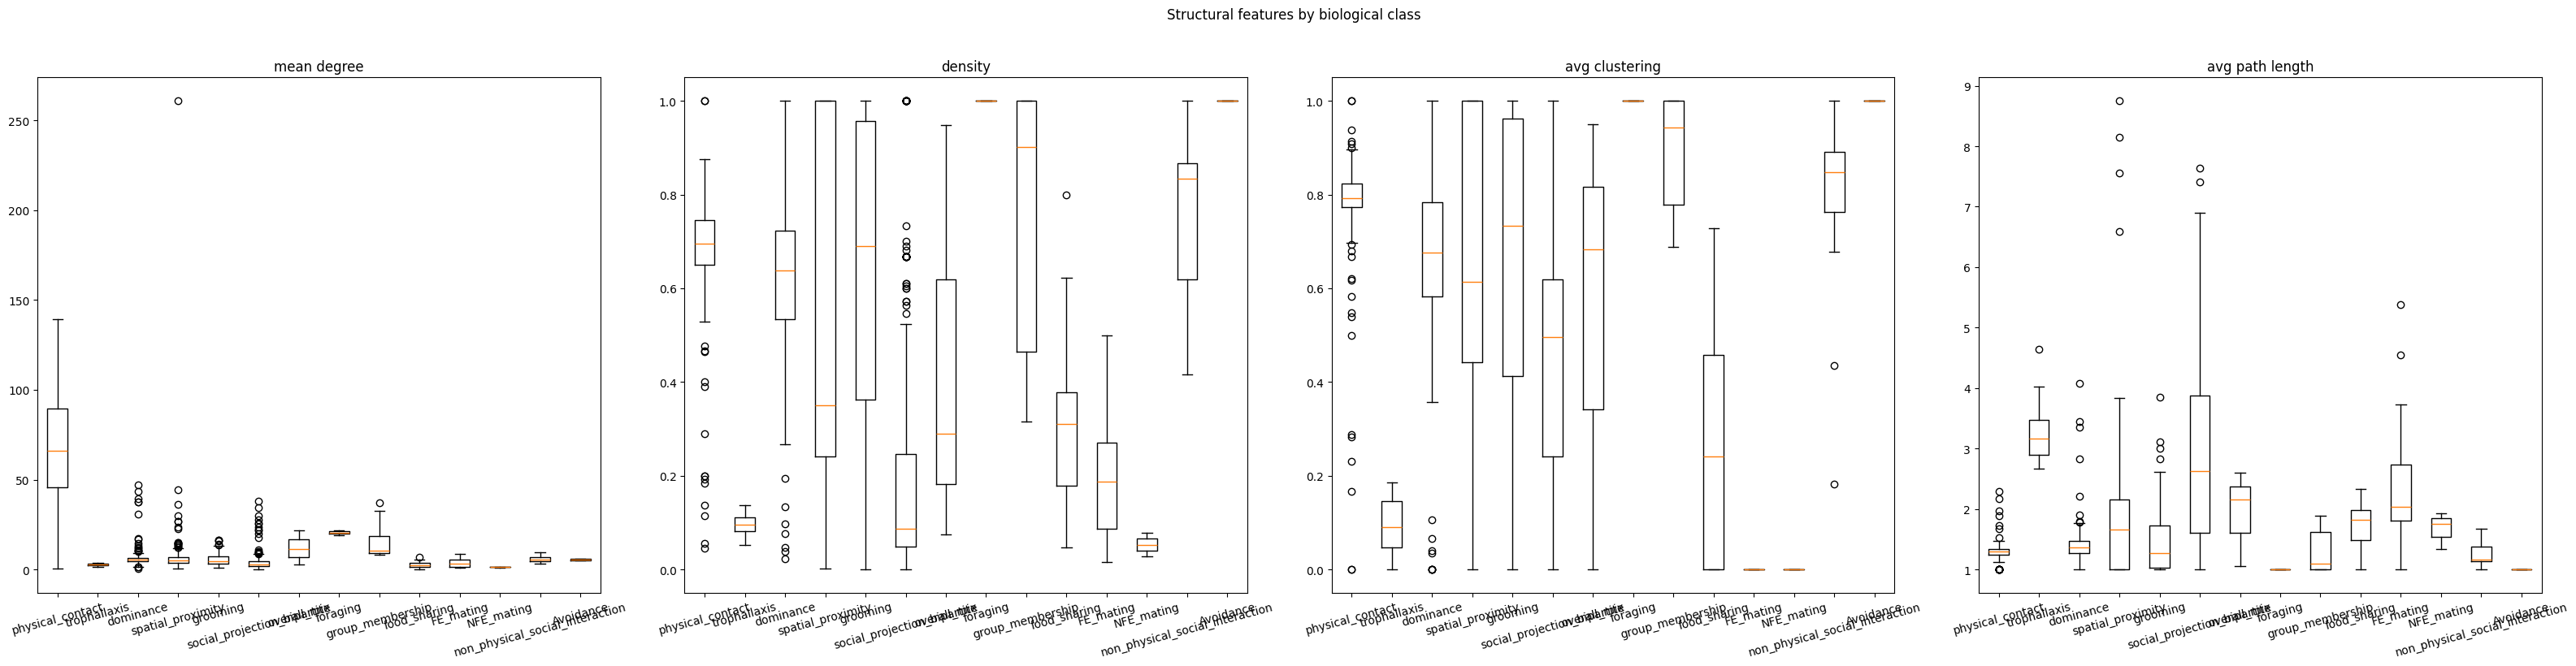

In [11]:
#Box plots of structural features per interaction type
features_to_plot = ['mean_degree', 'density', 'avg_clustering', 'avg_path_length']
bio_classes = feat_df['class'].dropna().unique()
inter_classes = feat_df['interaction_type'].dropna().unique()

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(32, 8))
for ax, feat in zip(axes, features_to_plot):
    data_per_class = [feat_df[feat_df['interaction_type'] == c][feat].dropna().values for c in inter_classes]
    ax.boxplot(data_per_class, labels=inter_classes)
    ax.set_title(feat.replace('_', ' '))
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Structural features by biological class', y=1.02)
plt.tight_layout()
plt.savefig('eda_structural_features_interaction.pdf', bbox_inches='tight')
plt.show()

### Graph Visualization

In [12]:
#Graph visualisations per interaction type
selected_interactions = [
    'physical_contact',
    'social_projection_bipartite',
    'spatial_proximity',
    'grooming',
    'dominance',
    'FE_mating',
]

selected_classes = [
    'Mammalia',
    'Insecta',
    'Aves'
]

filtered_df = info_frame[
    info_frame['interaction_type'].isin(selected_interactions) &
    info_frame['class'].isin(selected_classes) &
    (info_frame['nodes'] > 5) &
    pd.notna(info_frame['avg.edge.strength']) #Filter out graphs with no edges
].copy().rename(columns={'class': 'network_class'})

interaction_mapping = {c: i for i, c in enumerate(selected_interactions)}
filtered_df['interaction_map'] = filtered_df['interaction_type'].map(interaction_mapping)

print('Filtered dataset size:', len(filtered_df))
print(filtered_df['interaction_type'].value_counts())

Filtered dataset size: 924
interaction_type
social_projection_bipartite    288
physical_contact               270
spatial_proximity              153
grooming                       115
dominance                       50
FE_mating                       48
Name: count, dtype: int64


In [13]:
print(len(filtered_df[filtered_df['network_class'] == 'Mammalia']['species'].value_counts()))

53


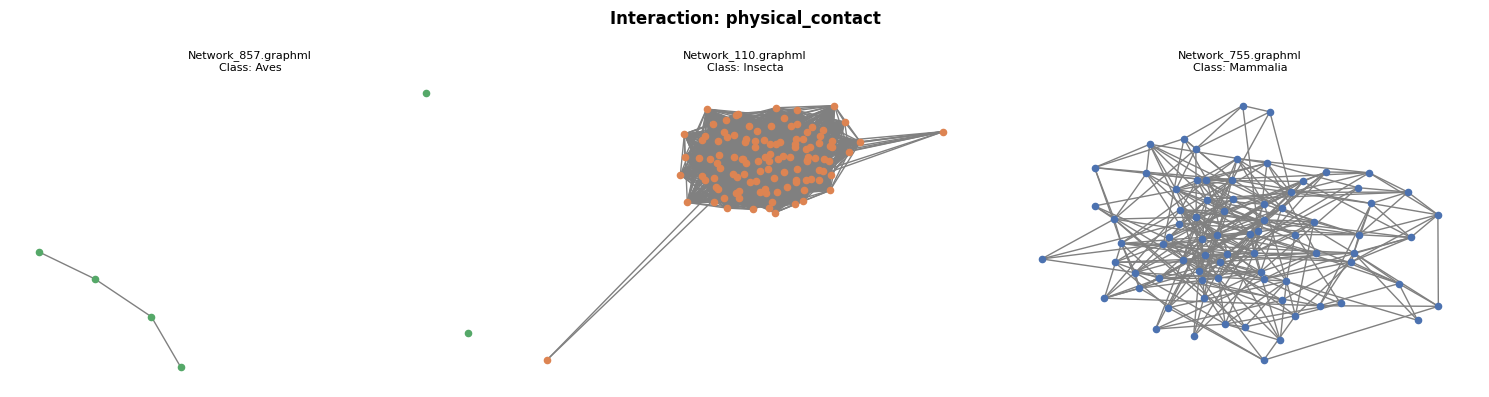

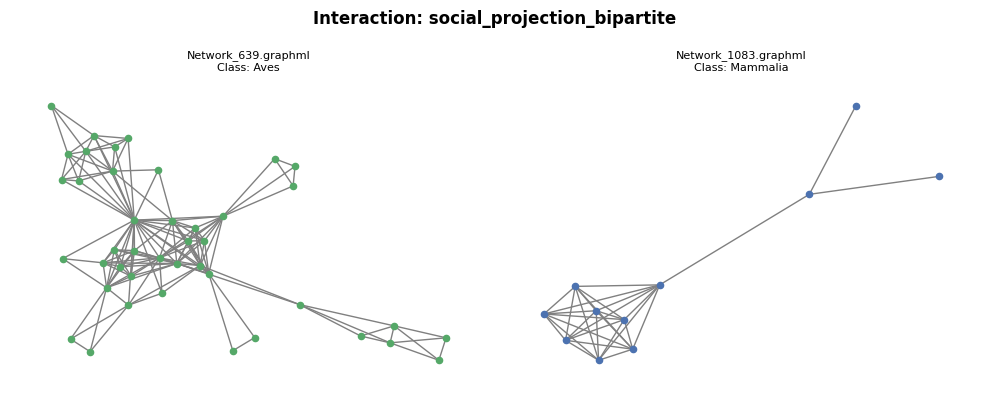

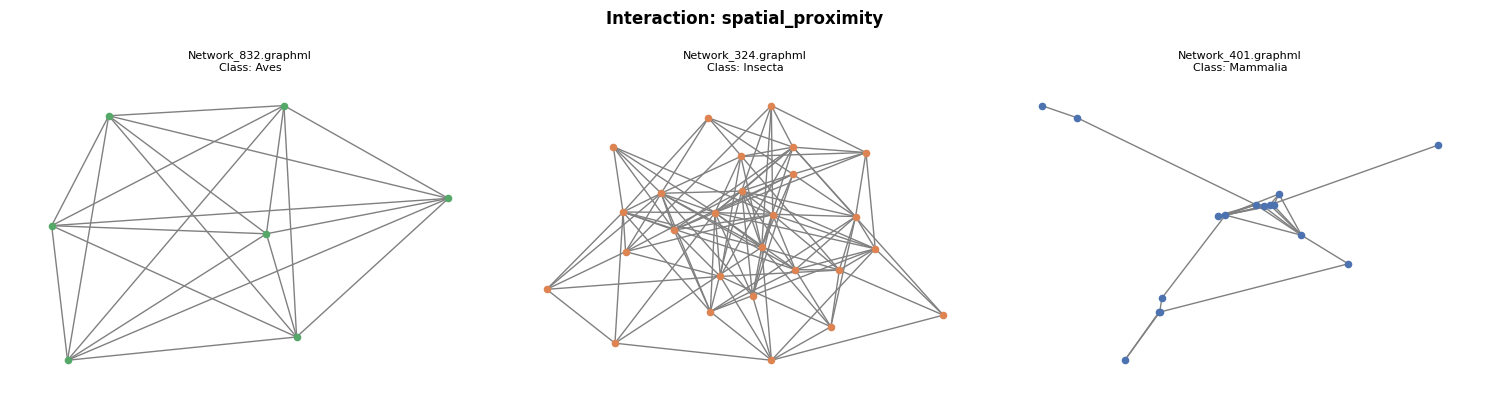

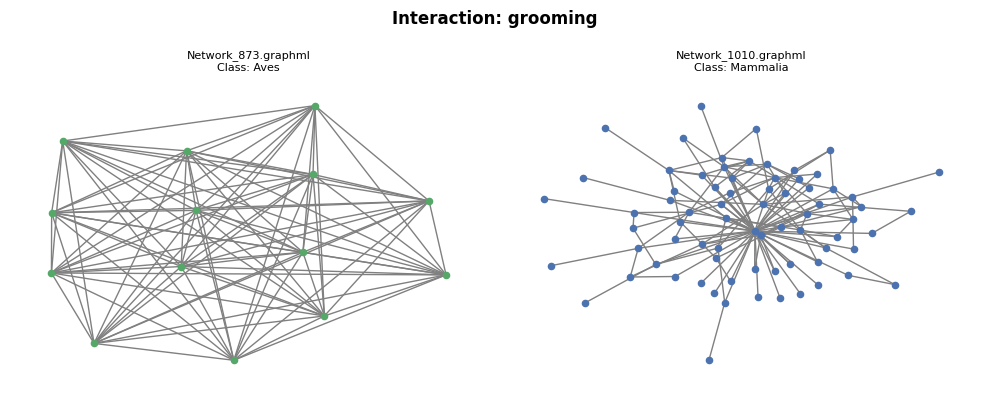

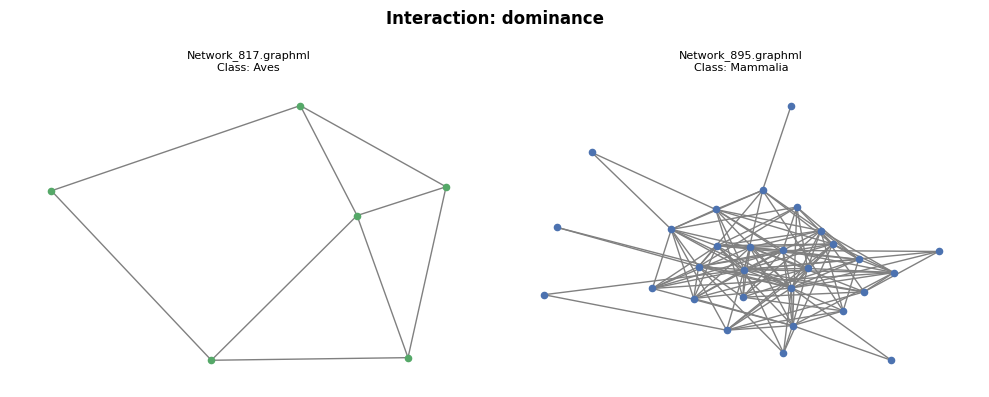

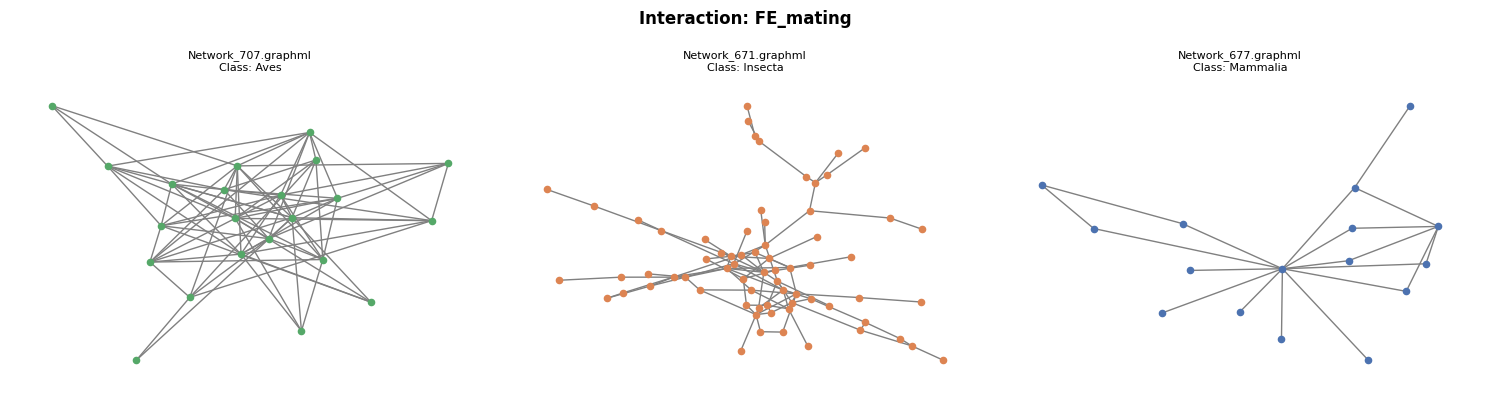

In [14]:
# Plot 2 examples per interaction type, coloured by biological class
samples_per_group = 1
sampled_df = (
    filtered_df
    .groupby(['network_class', 'interaction_type'], group_keys=False)
    .sample(n=samples_per_group, random_state=124)
    .reset_index(drop=True)
)


CLASS_COLORS = {'Mammalia': '#4C72B0', 'Insecta': '#DD8452', 'Aves': '#55A868'}

for interaction in selected_interactions:
    subset = sampled_df[sampled_df['interaction_type'] == interaction]
    if len(subset) == 0:
        continue
    n = len(subset)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    fig.suptitle(f'Interaction: {interaction}', fontsize=12, fontweight='bold')
    for ax, (_, row) in zip(axes, subset.iterrows()):
        g = asnr_graphs[row['Network_ID']]
        color = CLASS_COLORS.get(row['network_class'], 'lightgray')
        nx.draw(g, ax=ax, with_labels=False, node_size=20,
                node_color=color, edge_color='gray')
        ax.set_title(f"{row['Network_ID']}\nClass: {row['network_class']}", fontsize=8)
    plt.tight_layout()
    plt.show()